In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [3]:
# Dataset A: Symmetric (Normal)
A = np.random.normal(loc=50, scale=10, size=500)

# Dataset B: Right-skewed (Exponential scaled)
B = np.random.exponential(scale=1.0, size=500)
B = (B - B.min()) / (B.max() - B.min()) * 100

# Dataset C: Bimodal
C1 = np.random.normal(loc=30, scale=5, size=250)
C2 = np.random.normal(loc=70, scale=5, size=250)
C = np.concatenate([C1, C2])


def summarize(data):
    return {
        "Mean": round(np.mean(data), 2),
        "Median": round(np.median(data), 2),
        "Mode": round(stats.mode(data, keepdims=True)[0][0], 2),
        "Std": round(np.std(data), 2),
        "Variance": round(np.var(data), 2),
        "IQR": round(np.percentile(data, 75) - np.percentile(data, 25), 2),
        "Skewness": round(stats.skew(data), 2),
        "Kurtosis": round(stats.kurtosis(data), 2)
    }

summary_df = pd.DataFrame([
    summarize(A),
    summarize(B),
    summarize(C)
], index=["Dataset A", "Dataset B", "Dataset C"])

print(summary_df)

            Mean  Median   Mode    Std  Variance    IQR  Skewness  Kurtosis
Dataset A  50.07   50.13  17.59   9.80     96.09  13.37      0.18      0.26
Dataset B  16.17   11.29   0.00  15.97    255.13  18.65      1.77      3.98
Dataset C  50.33   49.53  15.52  20.28    411.19  39.01      0.01     -1.76


Task 1 Observation:
Symmetric dataset has mean ≈ median ≈ mode, while skewed and bimodal differ

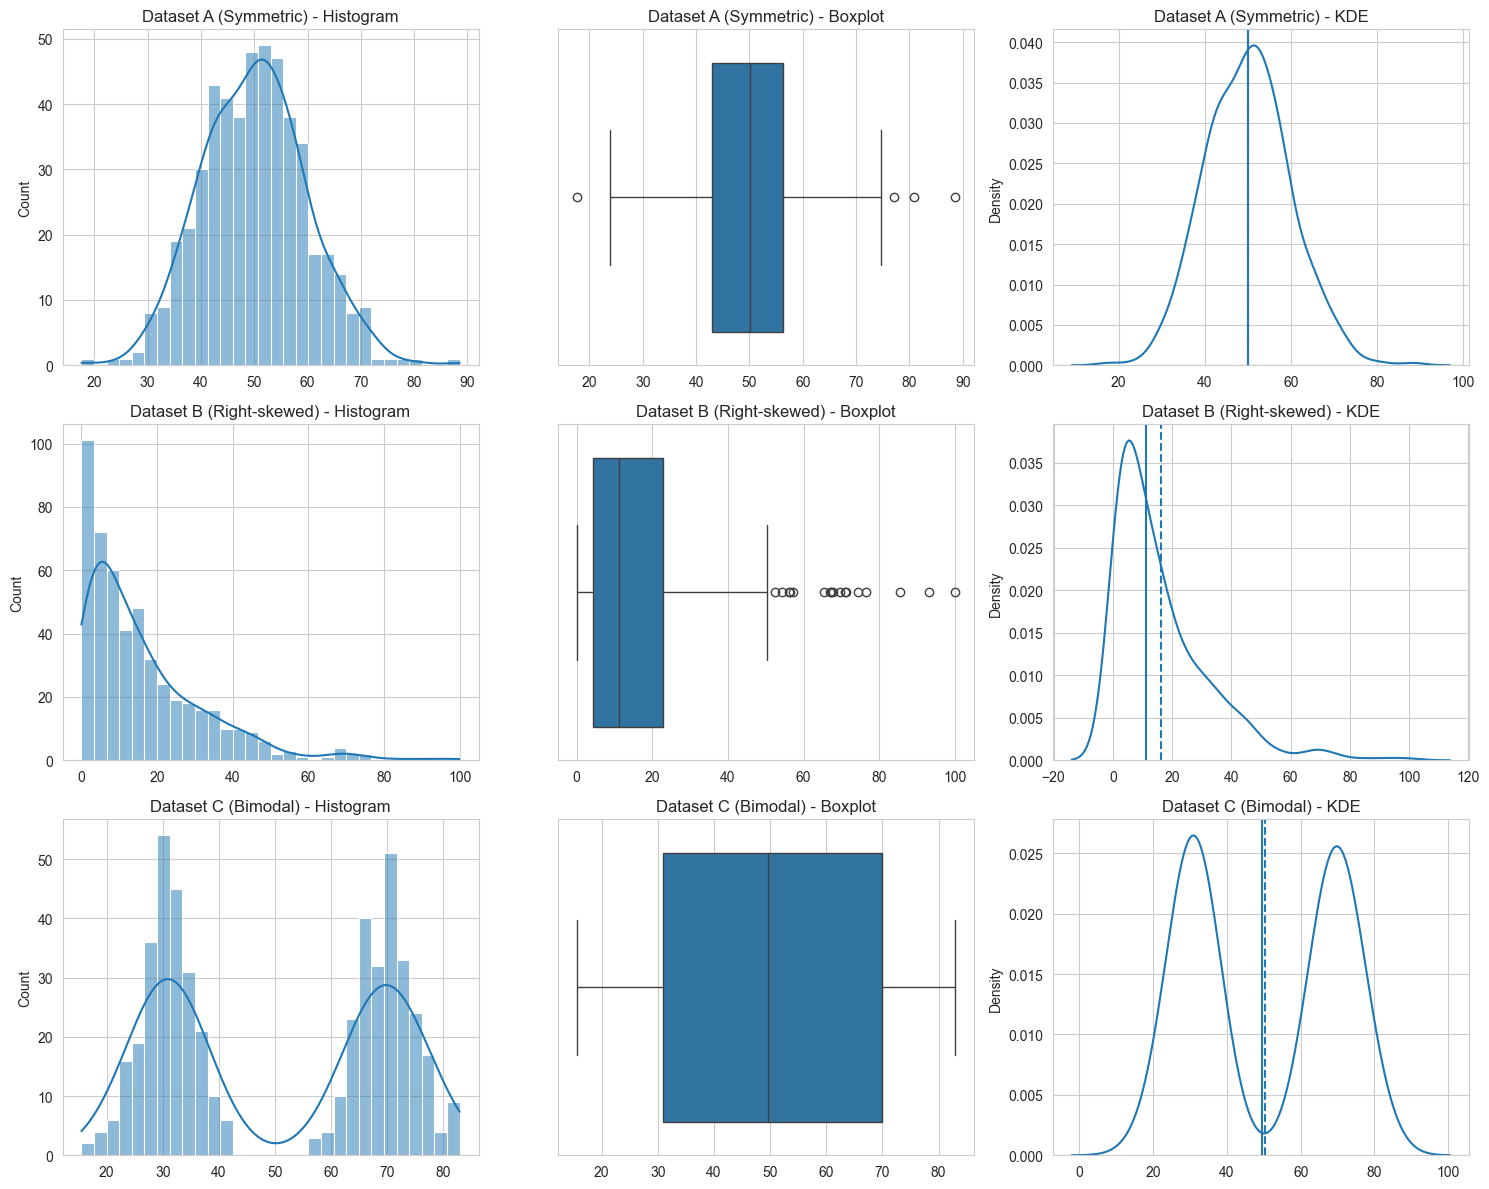

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
datasets = [A, B, C]
titles = ["Dataset A (Symmetric)", "Dataset B (Right-skewed)", "Dataset C (Bimodal)"]

for i, data in enumerate(datasets):
    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"{titles[i]} - Histogram")

    # Boxplot
    sns.boxplot(x=data, ax=axes[i, 1])
    axes[i, 1].set_title(f"{titles[i]} - Boxplot")

    # KDE with mean & median
    sns.kdeplot(data, ax=axes[i, 2])
    axes[i, 2].axvline(np.mean(data), linestyle='--')
    axes[i, 2].axvline(np.median(data))
    axes[i, 2].set_title(f"{titles[i]} - KDE")

plt.tight_layout()
plt.show()


Task 2 Observation:
Dataset B shows largest mean-median divergence due to long right tail.

             Mean  Median   Mode    Std  Variance    IQR  Skewness  Kurtosis
Original A  50.07   50.13  17.59   9.80     96.09  13.37      0.18      0.26
Modified A  57.17   50.13  17.59  74.31   5521.42  13.37      9.70     94.18


C:\Users\Scc\AppData\Local\Temp\ipykernel_19060\4081839901.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Original", "Modified"])


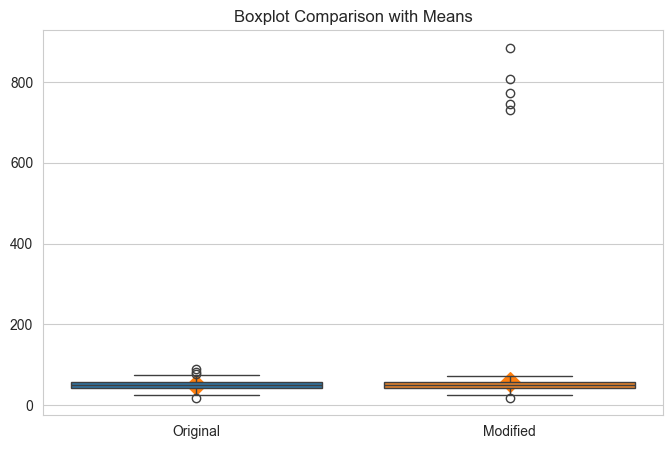

In [5]:
# Task 3: Outlier Stress Test

A_modified = A.copy()

# Replace 5 largest values with extreme outliers
largest_indices = np.argsort(A_modified)[-5:]
A_modified[largest_indices] *= 10

summary_original = summarize(A)
summary_modified = summarize(A_modified)

comparison_df = pd.DataFrame([summary_original, summary_modified], 
                             index=["Original A", "Modified A"])

print(comparison_df)

# Boxplots comparison
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=[A, A_modified], ax=ax)

# Overlay means
means = [np.mean(A), np.mean(A_modified)]
ax.scatter([0, 1], means, marker='D', s=100)

ax.set_xticklabels(["Original", "Modified"])
ax.set_title("Boxplot Comparison with Means")

plt.show()

Task 3 Observation:
Mean and variance changed dramatically; median and IQR stayed stable.
Median is more reliable for typical value under outliers.